# Absorption & dispersion → the low-light limit
### Griffiths §9.4.3 (the Lorentz oscillator), wired to the carrier-less receiver

Bound electrons in a medium are **damped driven oscillators**. Solving their
response gives a *complex* permittivity

$$\varepsilon_r(\omega)=1+\frac{\omega_p^2}{\omega_0^2-\omega^2-i\gamma\omega},
\qquad \tilde n=\sqrt{\varepsilon_r}=n+i\kappa.$$

- $n$ (real) → phase velocity → **dispersion** (the thing the GS receiver lives on),
- $\kappa$ (imag) → decay → **absorption** (Beer–Lambert).

They are two faces of one resonance — and **causality (Kramers–Kronig)** forbids
having one without the other. Absorption then removes photons, pushing the
detector into the **shot-noise-limited low-light regime** where phase recovery
gets hard. That is the whole arc of this notebook.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, matplotlib.pyplot as plt
from griffiths import electrodynamics as ed
import dispersion_gs_prototype as dg
import gs_core as gs
print("loaded")

loaded


## 1. The two shapes: dispersion $n(\omega)$ and absorption $\kappa(\omega)$

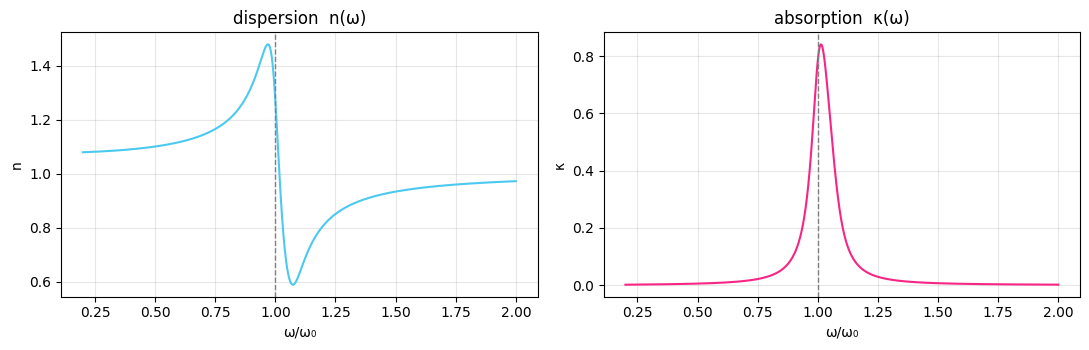

absorption peaks at ω=1.013 (resonance ω0=1.0)


In [2]:
w  = np.linspace(0.2, 2.0, 4000)
w0, gamma, wp = 1.0, 0.08, 0.4
eps = ed.lorentz_epsilon(w, w0, gamma, wp)
nt  = ed.complex_index(eps); n, kappa = nt.real, nt.imag

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(w, n, color='#4cc9f0'); ax[0].axvline(w0, ls='--', c='grey', lw=1)
ax[0].set_title('dispersion  n(ω)'); ax[0].set_xlabel('ω/ω₀'); ax[0].set_ylabel('n'); ax[0].grid(alpha=.3)
ax[1].plot(w, kappa, color='#f72585'); ax[1].axvline(w0, ls='--', c='grey', lw=1)
ax[1].set_title('absorption  κ(ω)'); ax[1].set_xlabel('ω/ω₀'); ax[1].set_ylabel('κ'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"absorption peaks at ω={w[np.argmax(kappa)]:.3f} (resonance ω0={w0})")

## 2. Anomalous dispersion + Kramers–Kronig

Across the absorption line $n$ briefly **falls** with frequency — *anomalous*
dispersion. And the absorption spectrum $\mathrm{Im}\,\chi$ alone reconstructs the
dispersion $\mathrm{Re}\,\chi$ (Hilbert transform): you cannot engineer one
without the other.

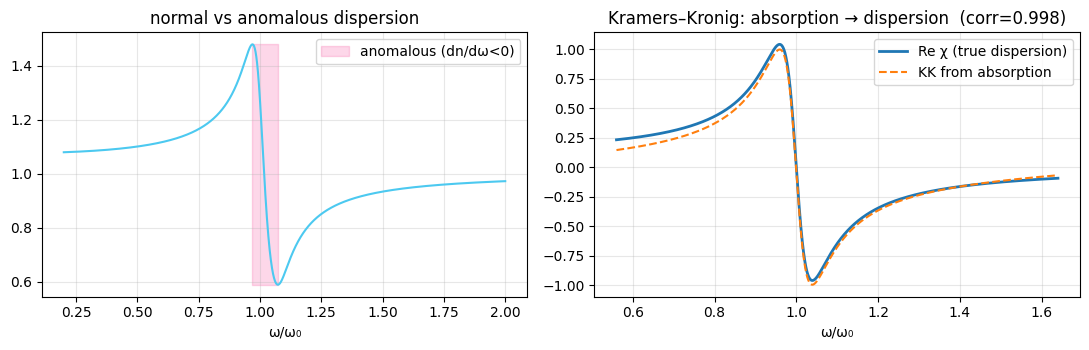

In [3]:
anom = ed.is_anomalous(w, n)
chi = eps - 1.0
re_kk = ed.kramers_kronig(chi.imag)
core = slice(len(w)//5, 4*len(w)//5)
corr = np.corrcoef(re_kk[core], chi.real[core])[0,1]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(w, n, color='#4cc9f0')
ax[0].fill_between(w, n.min(), n.max(), where=anom, color='#f72585', alpha=.18,
                   label='anomalous (dn/dω<0)')
ax[0].set_title('normal vs anomalous dispersion'); ax[0].set_xlabel('ω/ω₀'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(w[core], chi.real[core], label="Re χ (true dispersion)", lw=2)
ax[1].plot(w[core], re_kk[core], '--', label="KK from absorption", lw=1.5)
ax[1].set_title(f'Kramers–Kronig: absorption → dispersion  (corr={corr:.3f})')
ax[1].set_xlabel('ω/ω₀'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. Absorption removes photons (Beer–Lambert)

On resonance the intensity is attenuated $I(z)=I_0e^{-\alpha z}$, $\alpha=2\omega\kappa/c$.
Whatever survives is what the detector has to count — and if that's few photons,
we are in the **low-light** regime.

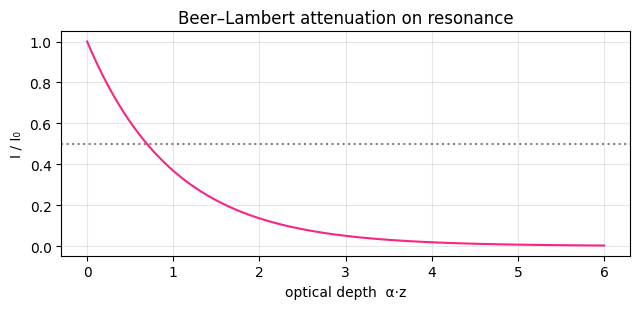

α(resonance) = 1.570;  half-intensity at αz = 0.693


In [4]:
k_res = kappa[np.argmin(np.abs(w - w0))]
alpha = ed.absorption_coefficient(w0, k_res, c=1.0)
z = np.linspace(0, 6/alpha, 200)
plt.figure(figsize=(6.5,3.2))
plt.plot(z*alpha, ed.beer_lambert(1.0, alpha, z), color='#f72585')
plt.axhline(0.5, ls=':', c='grey'); plt.xlabel('optical depth  α·z'); plt.ylabel('I / I₀')
plt.title('Beer–Lambert attenuation on resonance'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"α(resonance) = {alpha:.3f};  half-intensity at αz = {np.log(2):.3f}")

## 4. Low light → shot noise → phase-recovery degradation

A square-law detector counts **discrete photons**: the count is Poisson, so the
relative noise scales as $1/\sqrt{N_{\text{photons}}}$. We sweep the photon
budget, add `photon_shot_noise` to both intensities $I_1,I_2$, run
Gerchberg–Saxton, and watch the recovered-phase RMS climb as the light fades.

clean (high-light) RMS = 0.013 rad


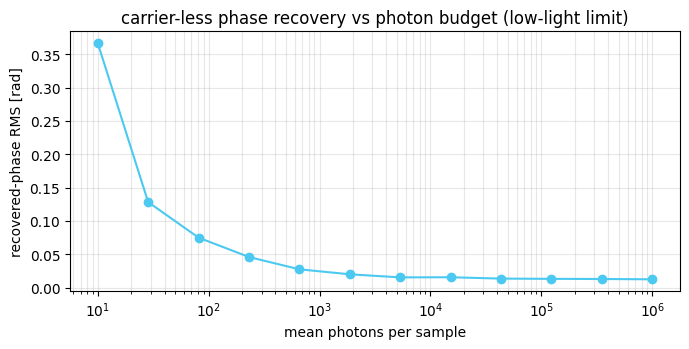

photons: [     10      28      81     231     657    1873    5336   15199   43287
  123284  351119 1000000]
RMS    : [0.367 0.128 0.075 0.046 0.028 0.02  0.015 0.016 0.014 0.013 0.013 0.013]


In [5]:
rng = np.random.default_rng(7)
# build the two intensities consistently (unit-amplitude field, dispersed to D1,D2)
data = gs.make_qpsk_measurements(n_symbols=128, sps=8, D1=-5000.0, D2=-5750.0, snr_db=60.0)
phi_true, D1, D2 = data["phi_true"], data["D1"], data["D2"]
I1c, I2c = np.maximum(data["I1"], 0), np.maximum(data["I2"], 0)

def recover_rms(I1, I2):
    phi, _ = gs.retrieve_phase(I1, I2, D1, D2, n_iter=80)   # unit_amplitude=True (default)
    best = None
    for s in (1, -1):                                   # resolve global offset + twin
        off = np.angle(np.mean(np.exp(1j*(phi_true - s*phi))))
        err = np.sqrt(np.mean(np.angle(np.exp(1j*(phi_true - (s*phi+off))))**2))
        best = err if best is None else min(best, err)
    return best

print(f"clean (high-light) RMS = {recover_rms(I1c, I2c):.3f} rad")
budgets = np.logspace(1, 6, 12)                          # 10 ... 1,000,000 photons
rms = np.array([np.mean([recover_rms(dg.photon_shot_noise(I1c, b, rng),
                                     dg.photon_shot_noise(I2c, b, rng))
                         for _ in range(3)]) for b in budgets])

plt.figure(figsize=(7,3.6))
plt.semilogx(budgets, rms, 'o-', color='#4cc9f0')
plt.xlabel('mean photons per sample'); plt.ylabel('recovered-phase RMS [rad]')
plt.title('carrier-less phase recovery vs photon budget (low-light limit)')
plt.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()
print('photons:', budgets.astype(int))
print('RMS    :', np.round(rms, 3))

## Takeaway

| concept | role here |
|---|---|
| Lorentz $\varepsilon_r(\omega)$ | the medium's response — one resonance |
| $\mathrm{Re}\,\tilde n=n$ | **dispersion** — the operator $H(f)=e^{i\pi Df^2}$ the receiver inverts |
| $\mathrm{Im}\,\tilde n=\kappa$ | **absorption** — Beer–Lambert photon loss |
| Kramers–Kronig | absorption and dispersion are causally locked |
| Poisson shot noise | absorption → few photons → noisy $I_1,I_2$ |
| GS RMS vs budget | the **low-light limit** of phase recovery |

So "absorption and dispersion" and "low light" are the same story told twice:
the resonance that bends the phase is the resonance that eats the photons.
Civilian optical metrology / education.